# Business Understanding

## Project Domain

Dataset ini dikurasi untuk memfasilitasi pengembangan model pembelajaran mesin yang bertujuan untuk memprediksi anemia berdasarkan kadar hemoglobin dan distribusi piksel warna dari gambar terkait. Setiap baris dalam dataset sesuai dengan kasus individual dengan berbagai fitur

## Problem Statements

Tentu! Berikut adalah contoh penulisan **masalah yang dihadapi penderita atau dalam penanganan penyakit anemia**, disusun dengan format dan gaya yang **serupa dengan contoh masalah pertanian** yang Anda berikan:

---

### **Masalah yang Dihadapi:**

#### **Kurangnya Deteksi Dini Anemia**  
Banyak penderita anemia tidak menyadari kondisinya karena gejalanya sering dianggap ringan seperti lemas, pusing, atau mudah lelah.  
Hal ini menyebabkan anemia tidak terdiagnosis hingga mencapai tahap yang lebih parah dan berdampak pada produktivitas harian.

#### **Ketergantungan pada Pemeriksaan Laboratorium**  
Diagnosis anemia umumnya memerlukan pemeriksaan laboratorium seperti tes kadar hemoglobin.  
Namun, akses terhadap layanan kesehatan dan laboratorium sering kali terbatas, terutama di daerah pedesaan atau terpencil.

#### **Gizi yang Tidak Seimbang**  
Kurangnya konsumsi makanan bergizi, khususnya makanan kaya zat besi, vitamin B12, dan asam folat, menjadi penyebab utama anemia.  
Hal ini sering terjadi akibat keterbatasan ekonomi atau kurangnya edukasi tentang pola makan sehat.

#### **Anemia pada Kelompok Rentan**  
Ibu hamil, anak-anak, dan remaja adalah kelompok rentan terhadap anemia, tetapi kesadaran untuk melakukan skrining berkala masih rendah.  
Akibatnya, risiko komplikasi pada kehamilan dan gangguan perkembangan anak meningkat.

#### **Minimnya Edukasi dan Sosialisasi**  
Kurangnya kampanye kesehatan atau penyuluhan tentang gejala dan pencegahan anemia membuat masyarakat tidak waspada terhadap kondisi ini.  
Hal ini memperlambat upaya pencegahan dan pengobatan sejak dini.

## Goals

Menggunakan model Artificial Neural Network (ANN) untuk memprediksi status anemia (anemia/tidak) berdasarkan data input pasien.

Membantu tenaga medis dan masyarakat umum dalam melakukan skrining awal anemia tanpa harus langsung ke laboratorium mahal.

Menyediakan alat bantu berbasis AI yang bisa diintegrasikan dalam aplikasi kesehatan digital.

Meningkatkan kesadaran masyarakat tentang deteksi dini anemia, khususnya di wilayah dengan akses terbatas terhadap layanan kesehatan.

## Solution Statements

Deteksi Anemia Secara Cepat dan Akurat
Menggunakan kecerdasan buatan untuk memprediksi risiko anemia hanya dari data sederhana seperti hemoglobin, usia, dan jenis kelamin.

Akses Mudah Bagi Pasien
Pasien bisa mengecek kondisi kesehatannya sendiri melalui aplikasi tanpa harus ke rumah sakit atau laboratorium.

Bantu Pasien Ambil Tindakan Lebih Cepat
Sistem memberikan saran awal berdasarkan hasil prediksi agar pasien bisa segera mendapatkan perawatan atau memperbaiki pola makan.

# Data Understanding

## Import data dari kaggle

In [159]:
from google.colab import files
files.upload()

{}

In [160]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [161]:
!kaggle datasets download -d humairmunir/anaemia-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/humairmunir/anaemia-prediction-dataset
License(s): MIT
anaemia-prediction-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [162]:
!mkdir anaemia-prediction-dataset
!unzip anaemia-prediction-dataset.zip -d anaemia-prediction-dataset
!ls anaemia-prediction-dataset

mkdir: cannot create directory ‘anaemia-prediction-dataset’: File exists
Archive:  anaemia-prediction-dataset.zip
replace anaemia-prediction-dataset/d_output.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: d_output.csv  expanded_output.csv  file_.csv


## Import Library yang dibutuhkan

In [163]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [164]:
df = pd.read_csv('/content/anaemia-prediction.zip')

In [165]:
df.head()

,Number,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,1,M,43.2555,30.8421,25.9025,6.3,Yes
1,2,F,45.6033,28.1900,26.2067,13.5,No
2,3,F,45.0107,28.9677,26.0215,11.7,No
3,4,F,44.5398,28.9899,26.4703,13.5,No
4,5,M,43.2870,30.6972,26.0158,12.4,No


<ipython-input-166-9e02ca3b8306>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Number', y='Anaemic', inner='stick', palette='Dark2')


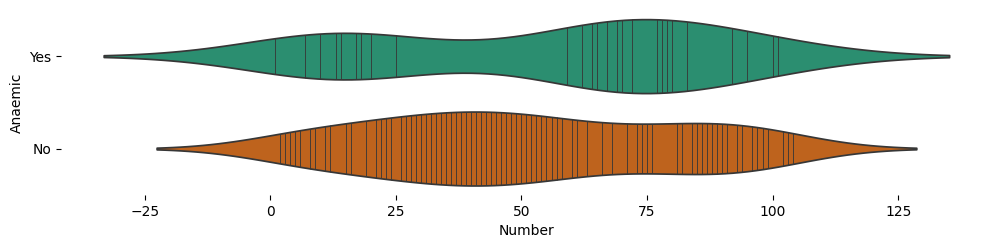

In [166]:
# @title Anaemic vs Number

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['Anaemic'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Number', y='Anaemic', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<ipython-input-167-b6ba92d31b48>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Number', y='Sex', inner='stick', palette='Dark2')


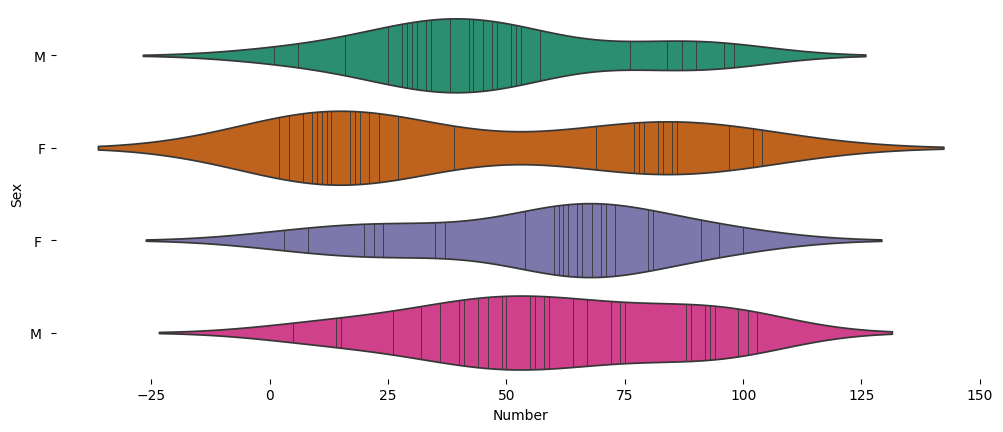

In [167]:
# @title Sex vs Number

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['Sex'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Number', y='Sex', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

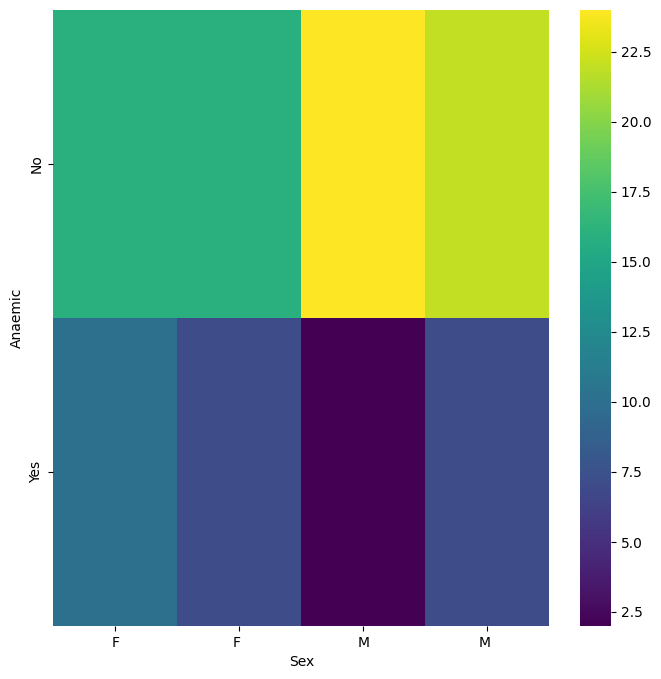

In [168]:
# @title Sex vs Anaemic

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Anaemic'].value_counts()
    for x_label, grp in df.groupby('Sex')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Sex')
_ = plt.ylabel('Anaemic')

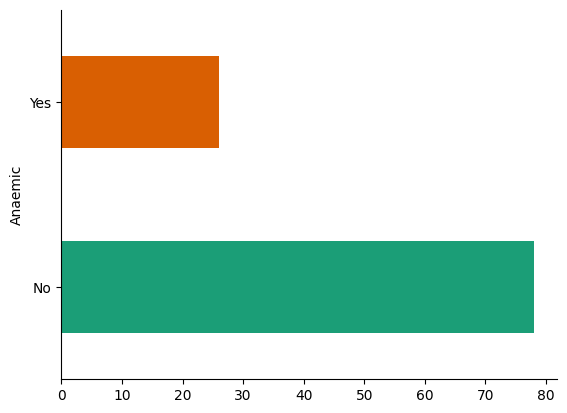

In [169]:
# @title Anaemic

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Anaemic').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

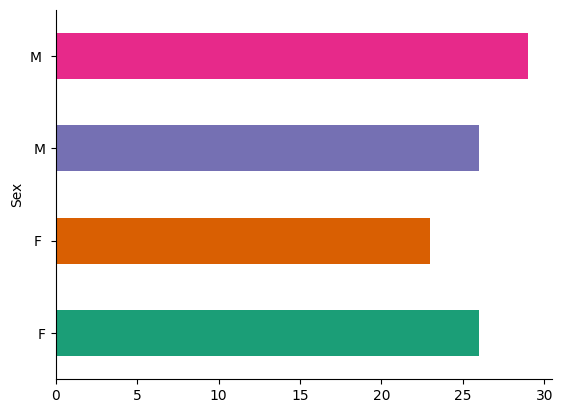

In [170]:
# @title Sex

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Sex').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Number        104 non-null    int64  
 1   Sex           104 non-null    object 
 2   %Red Pixel    104 non-null    float64
 3   %Green pixel  104 non-null    float64
 4   %Blue pixel   104 non-null    float64
 5   Hb            104 non-null    float64
 6   Anaemic       104 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 5.8+ KB


# Data Preparation

In [172]:
# # Data Preparation
df_encode = pd.DataFrame(df)
# Ubah isi kolom 'Sex' menjadi numerik (F=1, M=0)
df_encode['Sex'] = df_encode['Sex'].replace({'M': 0, 'F': 1,'M ': 0, 'F ': 1})
df_encode.head()

<ipython-input-172-f945644239a0>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encode['Sex'] = df_encode['Sex'].replace({'M': 0, 'F': 1,'M ': 0, 'F ': 1})


,Number,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,1,0,43.2555,30.8421,25.9025,6.3,Yes
1,2,1,45.6033,28.1900,26.2067,13.5,No
2,3,1,45.0107,28.9677,26.0215,11.7,No
3,4,1,44.5398,28.9899,26.4703,13.5,No
4,5,0,43.2870,30.6972,26.0158,12.4,No


In [173]:
# # Data Preparation
df_encode = pd.DataFrame(df)
# Ubah isi kolom 'Sex' menjadi numerik (F=1, M=0)
df_encode['Sex'] = df_encode['Sex'].replace({'M': 0, 'F': 1,'M ': 0, 'F ': 1})

# Drop the 'Number' column
df_encode = df_encode.drop('Number', axis=1)

df_encode.head()


<ipython-input-173-713e1dfc4f27>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encode['Sex'] = df_encode['Sex'].replace({'M': 0, 'F': 1,'M ': 0, 'F ': 1})


,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,0,43.2555,30.8421,25.9025,6.3,Yes
1,1,45.6033,28.1900,26.2067,13.5,No
2,1,45.0107,28.9677,26.0215,11.7,No
3,1,44.5398,28.9899,26.4703,13.5,No
4,0,43.2870,30.6972,26.0158,12.4,No


In [183]:
X = df_encode.drop(columns=["Anaemic"])
y = df_encode["Anaemic"]

In [184]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [185]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [186]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [187]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [188]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [189]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170 (43.63 KB)

 Trainable params: 11,170 (43.63 KB)

 Non-trainable params: 0 (0.00 B)

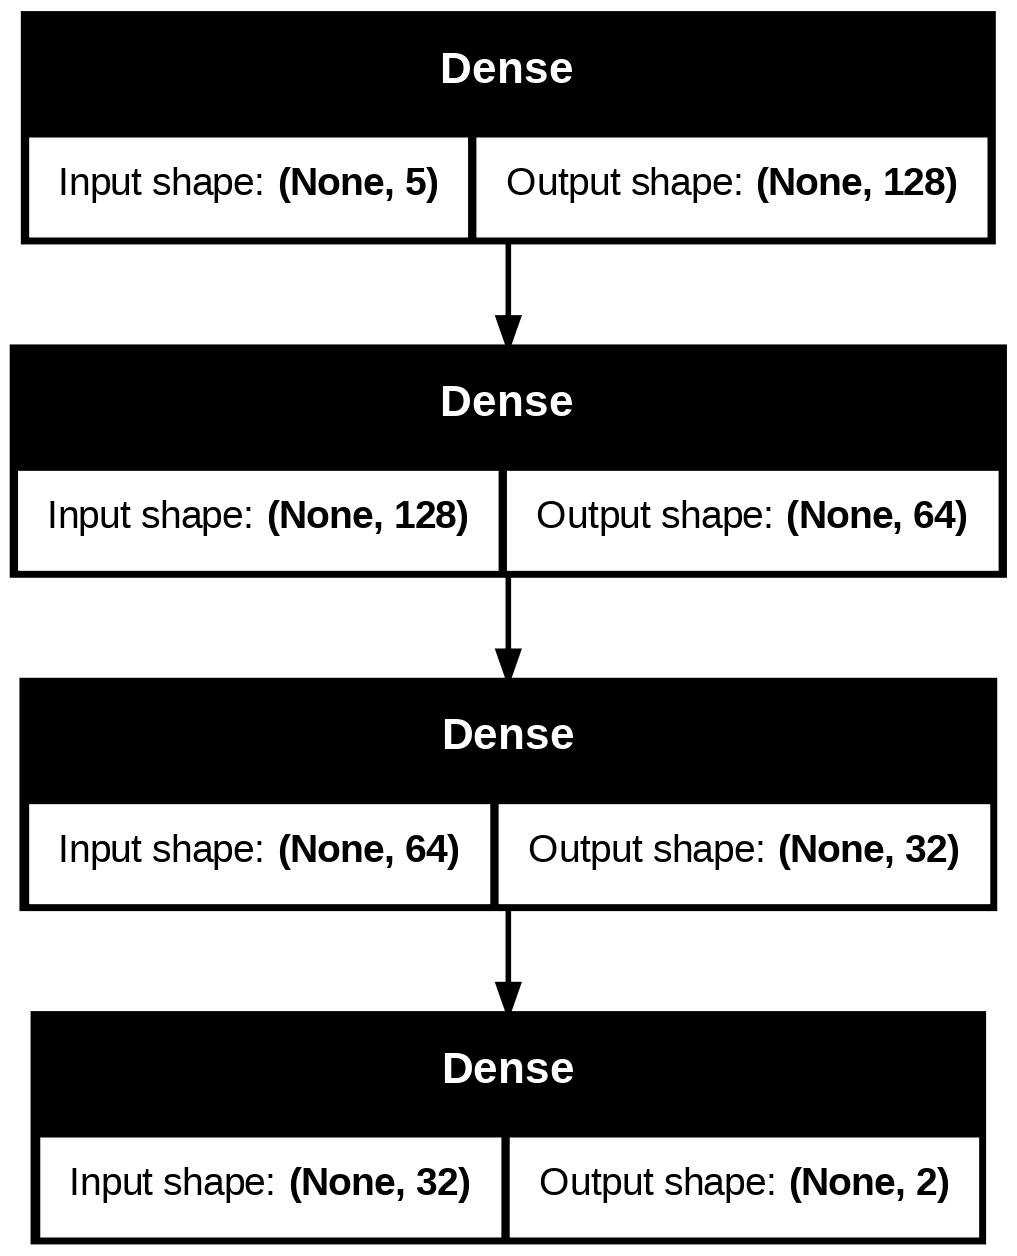

In [190]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [191]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.6608 - loss: 0.6670 - val_accuracy: 0.7619 - val_loss: 0.5902
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6811 - loss: 0.6145 - val_accuracy: 0.7619 - val_loss: 0.5400
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7640 - loss: 0.5425 - val_accuracy: 0.7619 - val_loss: 0.4924
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7179 - loss: 0.5339 - val_accuracy: 0.7619 - val_loss: 0.4581
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7561 - loss: 0.4821 - val_accuracy: 0.7619 - val_loss: 0.4276
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7402 - loss: 0.4917 - val_accuracy: 0.7619 - val_loss: 0.3980
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7573 - loss: 0.4294 - val_accuracy: 0.8095 - val_loss: 0.3650
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7831 - loss: 0.4099 - val_accuracy: 0.9048 - val_loss: 0.3286

# Evaluation

In [192]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 1.0000 - loss: 0.0250
Akurasi Model: 1.0000
Loss Model: 0.0250


In [193]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

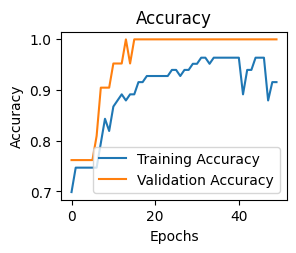

In [194]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

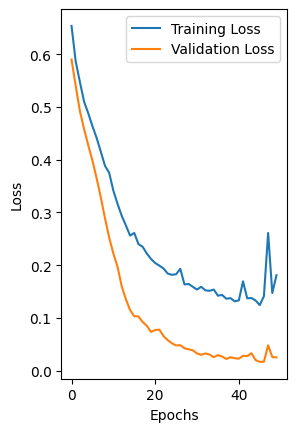

In [195]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


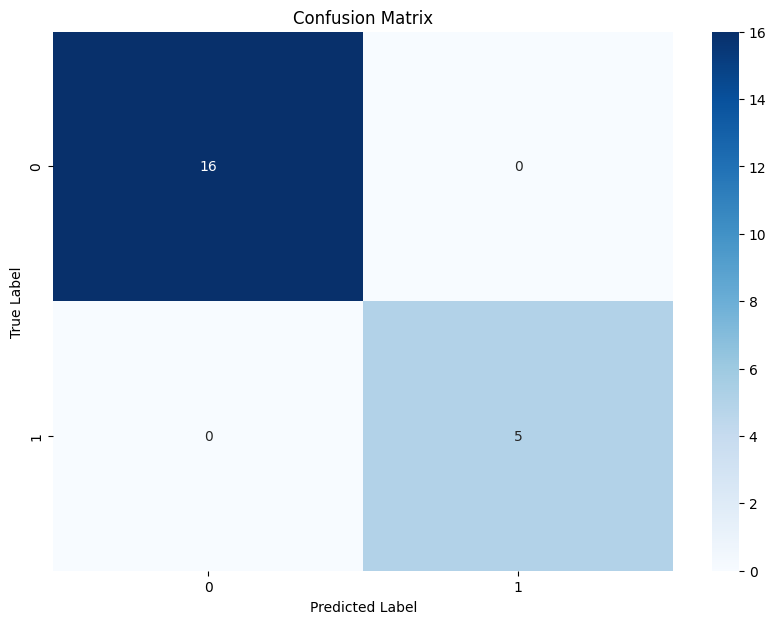

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         5

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [196]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [198]:
df_encode.head()

,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,0,43.2555,30.8421,25.9025,6.3,Yes
1,1,45.6033,28.1900,26.2067,13.5,No
2,1,45.0107,28.9677,26.0215,11.7,No
3,1,44.5398,28.9899,26.4703,13.5,No
4,0,43.2870,30.6972,26.0158,12.4,No


In [199]:
sample_input = np.array([[1, 42 ,30, 26, 6.5]])
sample_input_df = pd.DataFrame(sample_input)

In [200]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [203]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Terkena Penyakit Anemia : {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Terkena Penyakit Anemia : Yes


## Save Model

In [205]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('anemia.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpbwap_g3a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134238146885200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134238146886160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134238146885776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134238146886736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134238146885968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134238146884048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134238146885584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134238146885008: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [206]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']